Test JaxTracer on Hydro Turbulence

Import Libs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

#add path
sys.path.insert(0, '../')     # import path/to/sloth

import src.core.config as config
config.jax_init(force_device = "gpu")

import core.beam as beam_initialiser
import core.domain as d
import core.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /rds/general/user/sm13118/home/dev/SLOTH/src

Disabling python multi-threading...
Initialising jax...

Default jax backend: gpu
Available devices: [CudaDevice(id=0)]


<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/SLOTH/src/processing/diagnostics.py'>

Import domain

In [2]:
base_folder = "/rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC"
path_to_file = "/xyz12_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0203"
filename = base_folder+path_to_file
#  -----------------


columns = ["dims", "rays", "runtime", "legacyRuntime", "domainSize", "raySize", "totalMemory"]
df = pd.DataFrame(columns = columns)

#load hdf
ne, dims, spacing = utilIO.hdf_readin(filename, prefer_ye=True, force_override=True, verbose=True)

print(ne.shape)

'''
# multiply domain to match real size experimental target
multi_x = 0 # get multiplier x
multi_y = 0 # get multiplier y
multi_z = 0 # get multiplier z

for i in range(multi_x):
    ne = np.append(ne, ne, axis = 0)
for j in range(multi_y):
    ne = np.append(ne, ne, axis = 1)
for k in range(multi_z):
    ne = np.append(ne, ne, axis = 2)
'''

dims = ne.shape

extent_x = ((dims[0]*spacing[0].v)/2) * 1e-2
extent_y = ((dims[1]*spacing[1].v)/2) * 1e-2
extent_z = ((dims[2]*spacing[2].v)/2) * 1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 1e5

# del ne_x
# del ne_y
# del ne_z
# del ne

yt : [INFO     ] 2026-03-04 20:29:48,434 Parameters: current_time              = 1.8049559705796948e-07
yt : [INFO     ] 2026-03-04 20:29:48,434 Parameters: domain_dimensions         = [1200  750  500]
yt : [INFO     ] 2026-03-04 20:29:48,435 Parameters: domain_left_edge          = [-0.1  0.   0. ]
yt : [INFO     ] 2026-03-04 20:29:48,435 Parameters: domain_right_edge         = [1.1  0.75 0.5 ]
yt : [INFO     ] 2026-03-04 20:29:48,436 Parameters: cosmological_simulation   = 0


[hdf_readin] Loaded: /rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC/xyz12_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0203
[hdf_readin] has_ye=True (prefer_ye=True)
[hdf_readin] max_level=0
[hdf_readin] dims=(1200, 750, 500)
[hdf_readin] spacing=[unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length')]
(1200, 750, 500)
[0.012  0.0075 0.005 ]
extent x: 0.006000000000000001
extent y: 0.00375
extent z: 0.0025
dims x: 1200
dims y: 750
dims z: 500





In [3]:
domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6)

Predicted size in memory of domain: 1.6763806343078613 GB

Memory prior to domain creation:
 - total : 44.98828125 GB
 - free  : 44.149658203125 GB
 - used  : 858.75 MB

Est. ray size in memory: 210.5712890625 MB
Est. domain memory limit: 10.058283805847168 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 10.675191879272461 GB

padded up-to 1200 entries.(1200, 750, 500) --> 
 --> x padded with: 0 nan's
 --> y padded with: 450 nan's
 --> z padded with: 700 nan's

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


Tracing using JaxTracer

1.1398088520197473e+27


np.float64(0.0025)

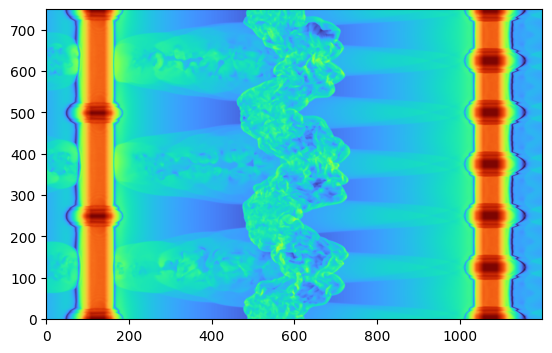

In [4]:
print(domain.ne.T.max())
plt.imshow(domain.ne[:,:,20].T, origin="lower",cmap='turbo', norm="log")
extent_z

In [5]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"

rf_jax, _, duration = p.solve((beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain, probing_extent, verbose = False)


Number of domain batches: 1
Number of ray batches: 1

Using tuple values to create the unbatched beam, domain must be used in the same fashion.

Est. size in memory of rays (1 = 736 B): 70.1904296875 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.0025 mm's to the target depth of 0.0025 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0003695487976074219 secondsTrue
True
True

Completed ray trace in 5.869 seconds.


### Inspects Histograms - Shadow and Refractogram

Text(0, 0.5, '$\\phi$ (mrad)')

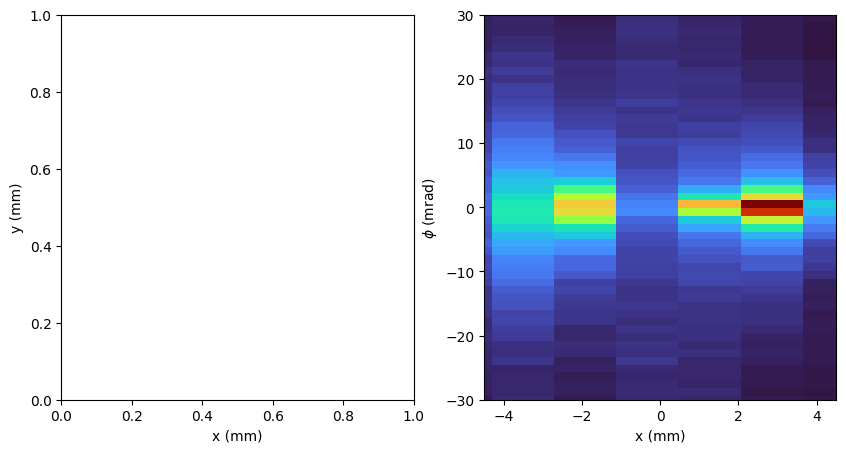

In [7]:
import matplotlib.colors as mcolors

nbins_x=3448
nbins_y=2574

# ----------------------

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))

_,_,_,img1 = ax2.hist2d(rf_jax[0]*1e3, rf_jax[2]*1e3, bins=(nbins_x, nbins_y), cmap ="turbo");

# ax1.set_ylim([-6.75, 6.75])
# ax1.set_xlim(-4.5, 4.5)
# ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_aspect('auto')

ax1.set_xlabel(r"x (mm)")
ax1.grid(False)
ax1.set_ylabel(r"y (mm)")

_,_,_,img1 = ax2.hist2d(rf_jax[0]*1e3, rf_jax[3]*1e3, bins=(nbins_x, nbins_y), norm=mcolors.PowerNorm(1), cmap ="turbo");

ax2.set_xlim(-4.5, 4.5)
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_aspect('auto')

ax2.set_xlabel(r"x (mm)")
ax2.set_ylim(-30,30)
ax2.set_yticks([-30, -20,-10,0,10,20,30])
ax2.grid(False)
ax2.set_ylabel(r"$\phi$ (mrad)")

In [8]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(lwl, rf_jax, focal_plane = 5)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

refractometer = diag.Refractometry(lwl, rf_jax, focal_plane = -5)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)



100000 rays received, 74907 incident on the first lens.
 --> 25.1 % of rays wasted!

rf size expected: [74907. 74907.]
rf after clearing nan's: [74907. 74907.]

100000 rays received, 74907 incident on the first lens.
 --> 25.1 % of rays wasted!

rf size expected: [74907. 74907.]
rf after clearing nan's: [74902. 74902.]


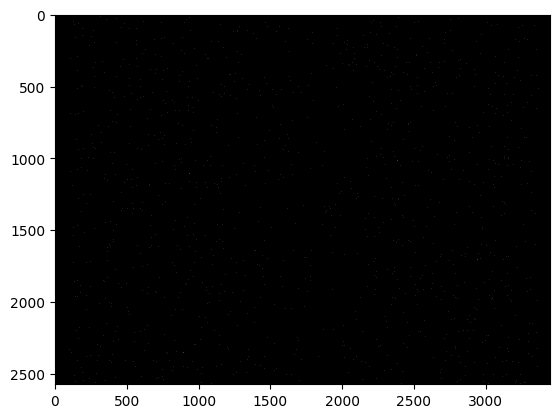

In [9]:
plt.imshow(shadowgrapher.H, cmap = 'Grays_r', interpolation = 'nearest', clim = [0, 10])

### Comparison with Legacy code

In [10]:
import legacy.full_solver as fs
import legacy.rtm_solver as rtm

In [11]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"

Np = int(1e5)

field = fs.ScalarDomain(ne_x, ne_y, ne_z, ne_extent)
field.external_ne(ne.v*1e6) # m^-3
field.calc_dndr(lwl)

## Initialise rays and solve
s0 = fs.init_beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)


field.solve(s0)
rf = field.rf

Starting ray trace.
Ray trace completed in:	 128.36288046836853 s


In [12]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(lwl, rf, focal_plane = 5)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

refractometer = diag.Refractometry(lwl, rf, focal_plane = -5)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)


100000 rays received, 87877 incident on the first lens.
 --> 12.1 % of rays wasted!

rf size expected: [87877. 87877.]
rf after clearing nan's: [87877. 87877.]

100000 rays received, 87877 incident on the first lens.
 --> 12.1 % of rays wasted!

rf size expected: [87877. 87877.]
rf after clearing nan's: [87875. 87875.]


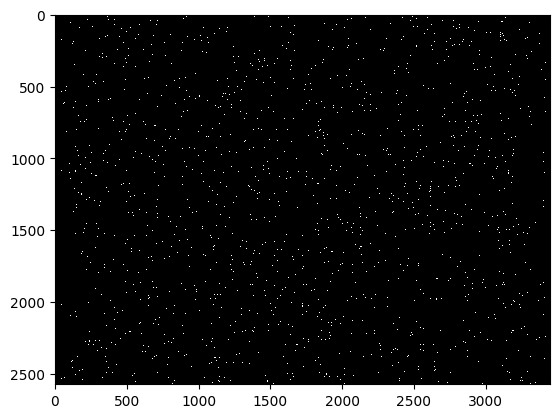

In [14]:
plt.imshow(shadowgrapher.H, cmap = 'Grays_r', interpolation = 'nearest', clim = [0,1])

In [15]:
sh=rtm.Shadowgraphy(rf, R = 25, focal_plane = 0, L = 400)
sh.single_lens_solve()
sh.histogram(bin_scale = 1, clear_mem=True)

rh = rtm.Refractometry(rf, R = 25, focal_plane = 0, L = 400)
rh.incoherent_solve()
rh.histogram(bin_scale = 1, clear_mem=True)

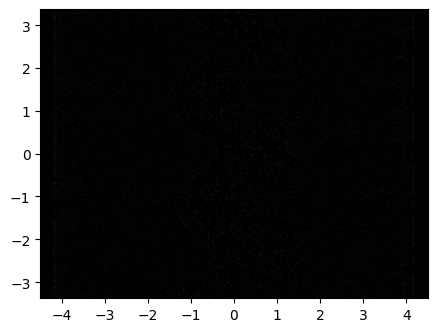

In [16]:
from utils.imaging import Image

scale_sh_x   =  sh.H.shape[1]/9
scale_sh_y   =  sh.H.shape[0]/6.75

L = 400 # distance from the volume to the lens (for a single lens system - 300 mm)

pixel_size  = (13.5/rh.H.shape[0])  # pixel size, mm/px in this case because bin = 10, pixel size = 52 um instead 5.4 um
scale_phi   =   1/(2 * pixel_size/L * 1000)  #sensitivity is Lϕ/2, ϕ in radians, convert to mradians.

shadow_sh  =     Image(sh.H, 0, scale_sh_x, scale_sh_y, fliplr = True)
o_sh       =     (int(sh.H.shape[1]/2), int(sh.H.shape[0]/2))
shadow_sh.set_origin(o_sh)

fig, ax = plt.subplots(1,1, figsize = (5,5))
shadow_sh.plot_mm(ax, cmap = 'Greys_r', aspect = scale_sh_y/scale_sh_x, clim = [0,0.1]);


Text(0, 0.5, '$\\phi$ (mrad)')

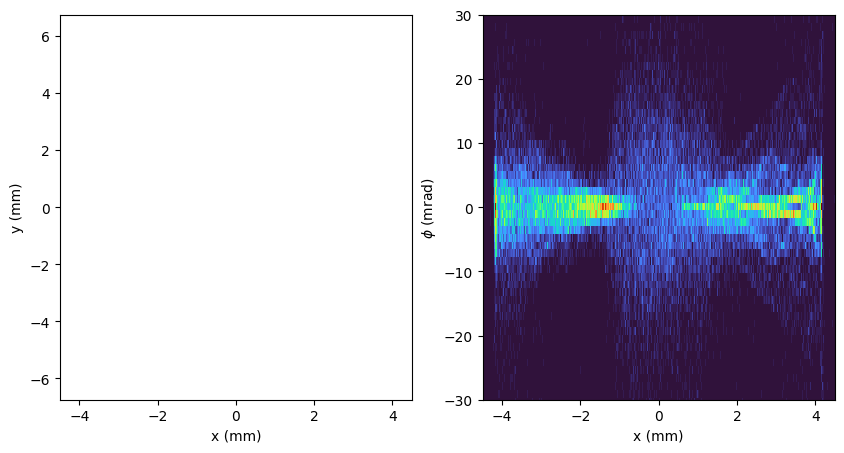

In [36]:
import matplotlib.colors as mcolors

nbins_x=3448
nbins_y=2574

# ----------------------

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))

_,_,_,img1 = ax2.hist2d(rf[0]*1e3, rf[2]*1e3, bins=(nbins_x, nbins_y), cmap ="turbo");

ax1.set_ylim([-6.75, 6.75])
ax1.set_xlim(-4.5, 4.5)
ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_aspect('auto')

ax1.set_xlabel(r"x (mm)")
ax1.grid(False)
ax1.set_ylabel(r"y (mm)")

_,_,_,img1 = ax2.hist2d(rf[0]*1e3, rf[3]*1e3, bins=(nbins_x, nbins_y), norm=mcolors.PowerNorm(1), cmap ="turbo");

ax2.set_xlim(-4.5, 4.5)
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_aspect('auto')

ax2.set_xlabel(r"x (mm)")
ax2.set_ylim(-30,30)
ax2.set_yticks([-30, -20,-10,0,10,20,30])
ax2.grid(False)
ax2.set_ylabel(r"$\phi$ (mrad)")

np.float64(-1.5611996208863324)